# **Airline Passengers**

A base de dados Airline Passengers (também conhecida como "International Airline Passengers") é um conjunto de dados clássico para análise e previsão de séries temporais, a base contém o mensal de passageiros de companhias aéreas internacionais (em milhares; abrange o período de Janeiro 1949 a Dezembro 1960 (12 anos), portanto, conta com 144 observações resultadod e (12 meses × 12 anos).

**Características:**

* Tendência crescente clara.

* Sazonalidade anual (picos em períodos de férias).

* Não estacionária (média e variância mudam ao longo do tempo)


In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from ucimlrepo import fetch_ucirepo

In [2]:
#Importanto a base de deprecated_endpoints
print("="*70)
print("CARREGAR E EXPLORAR OS DADOS")
print("="*70)


import pandas as pd
import numpy as np
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
base = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

df = base.copy()
passengers = df['Passengers'].values.astype('float32')

CARREGAR E EXPLORAR OS DADOS


In [3]:
print(f"\n ANÁLISE DO DATASET AIR PASSENGERS:")
print(f"   • Período: {df.index.min().strftime('%Y-%m')} até {df.index.max().strftime('%Y-%m')}")
print(f"   • Total de meses: {len(df)}")
print(f"   • Média: {np.mean(passengers):.1f} passageiros")
print(f"   • Mínimo: {np.min(passengers)} passageiros")
print(f"   • Máximo: {np.max(passengers)} passageiros")
print(f"   • Desvio Padrão: {np.std(passengers):.1f}")


 ANÁLISE DO DATASET AIR PASSENGERS:
   • Período: 1949-01 até 1960-12
   • Total de meses: 144
   • Média: 280.3 passageiros
   • Mínimo: 104.0 passageiros
   • Máximo: 622.0 passageiros
   • Desvio Padrão: 119.5


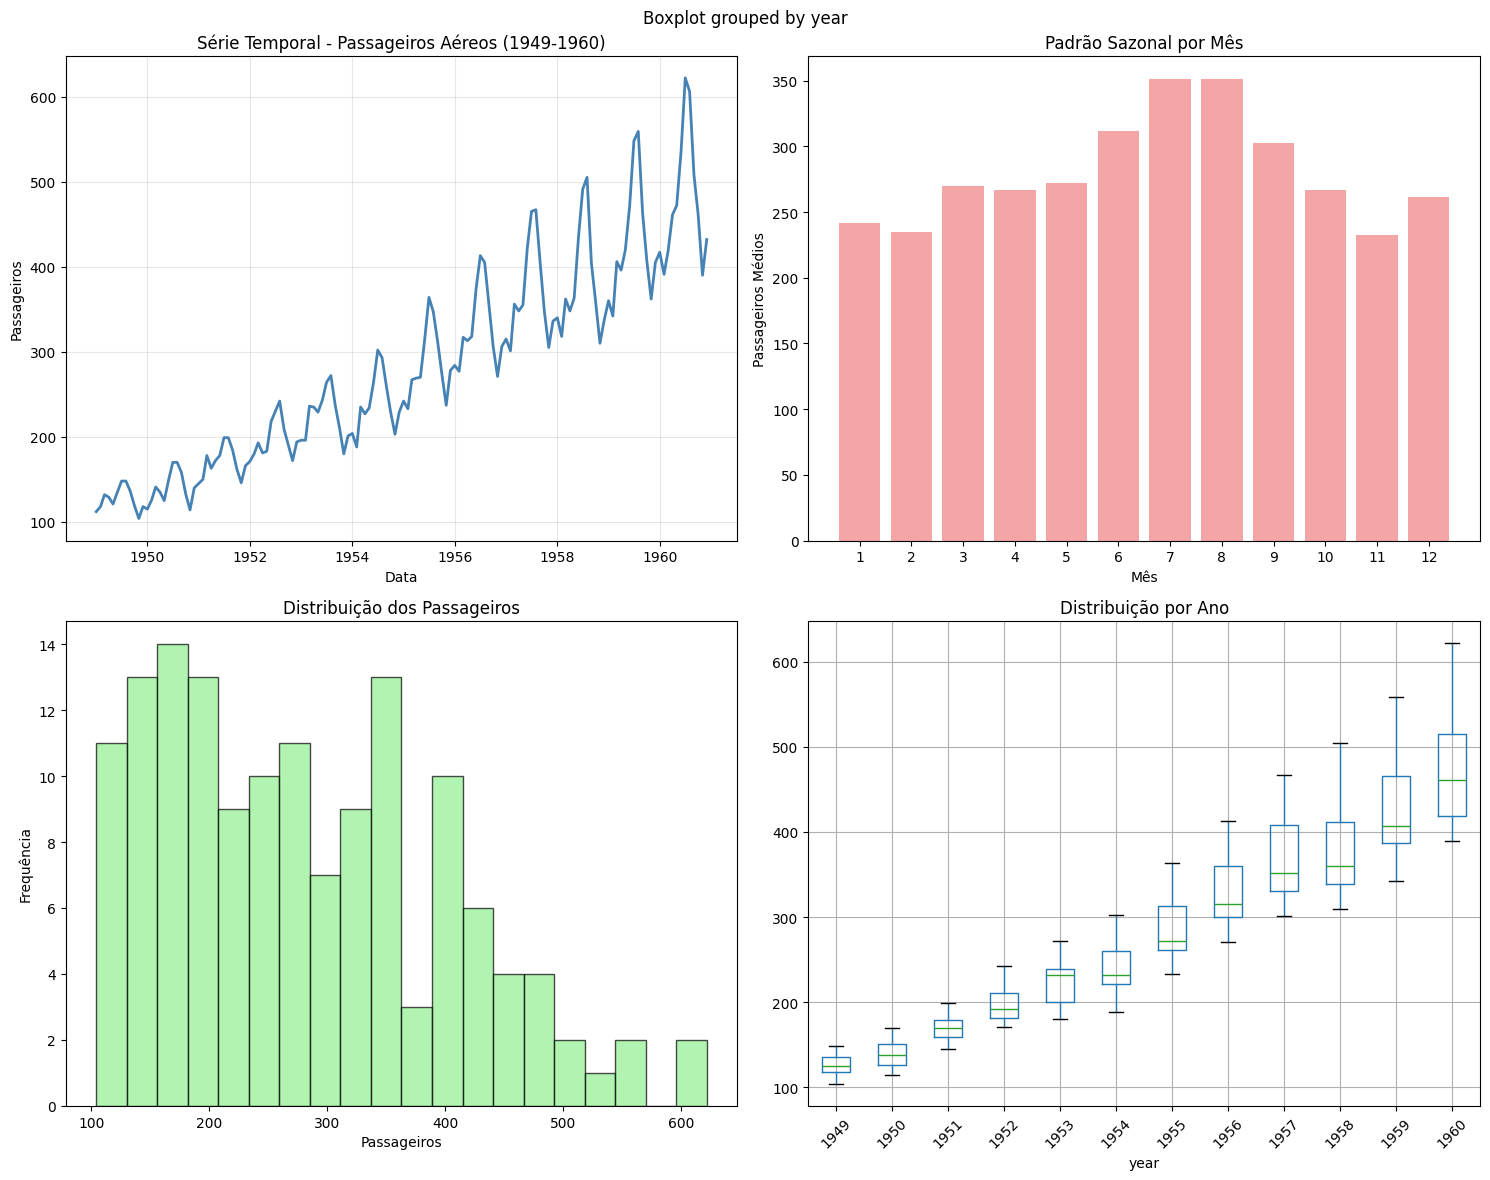

In [4]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Série temporal original
axes[0, 0].plot(df.index, passengers, linewidth=2, color='steelblue')
axes[0, 0].set_title('Série Temporal - Passageiros Aéreos (1949-1960)')
axes[0, 0].set_xlabel('Data')
axes[0, 0].set_ylabel('Passageiros')
axes[0, 0].grid(True, alpha=0.3)

# Decomposição sazonal
df['month'] = df.index.month
seasonal_avg = df.groupby('month')['Passengers'].mean()
axes[0, 1].bar(range(1, 13), seasonal_avg, color='lightcoral', alpha=0.7)
axes[0, 1].set_title('Padrão Sazonal por Mês')
axes[0, 1].set_xlabel('Mês')
axes[0, 1].set_ylabel('Passageiros Médios')
axes[0, 1].set_xticks(range(1, 13))

# Distribuição
axes[1, 0].hist(passengers, bins=20, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribuição dos Passageiros')
axes[1, 0].set_xlabel('Passageiros')
axes[1, 0].set_ylabel('Frequência')

# Boxplot por ano
df['year'] = df.index.year
df.boxplot(column='Passengers', by='year', ax=axes[1, 1])
axes[1, 1].set_title('Distribuição por Ano')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## **Particionando a base de dados**
* **X_treinamento, y_treinamento**
* **X_teste, y_teste**

In [5]:
#Serão utilizados aproximadamente 80% dos dados para teinamento e 20% dos dados para teste
#144*0.80= 115.6, portanto aproximadamente 116
nn_base_treinamento = 116
base_treinamento =base.iloc[0:nn_base_treinamento,0].values

In [6]:
base_treinamento.shape

(116,)

In [7]:
base_treinamento =base_treinamento.reshape(-1,1)

In [8]:
base_treinamento.shape

(116, 1)

## **Definindo o normalizador**

In [9]:
from sklearn.preprocessing import MinMaxScaler
normalizador =MinMaxScaler(feature_range=(0,1))
normalizador_previsores = MinMaxScaler(feature_range=(0,1))

In [10]:
base_treinamento_normalizada =normalizador.fit_transform(base_treinamento)

## **Adequando a base treiname do modelo**

In [11]:
#intervalo utilizado para relizar as previsões futuras é de 12 meses
intervalo_previsao =12

In [12]:
X_treinamento=[] #previsores
y_treinamento =[] #preço real

for i in range(intervalo_previsao,nn_base_treinamento):
    X_treinamento.append(base_treinamento_normalizada[i-intervalo_previsao:i,0])
    y_treinamento.append(base_treinamento_normalizada[i,0])

# Ao final deste loop X conterá em cada uma de suas entradas,
# uma lista do 12 registros.

In [13]:
#Convertendo X e y de Listas para Arrays
X_treinamento = np.array(X_treinamento)
y_treinamento =np.array(y_treinamento)

## **Construindo as bases de teste (X_teste, y_teste)**

In [14]:
base_teste = base.iloc[nn_base_treinamento:,0].values

In [15]:
y_teste = base_teste.copy()

## **Adequando a entrada da base de teste**

In [16]:
base_teste =base_teste.reshape(-1,1)

In [17]:
base_completa = base

In [18]:
len(base_completa), len(base_teste)

(144, 28)

In [19]:
entradas = base_completa[len(base_completa) - len(base_teste) - intervalo_previsao:].values

In [20]:
entradas = entradas.reshape(-1, 1)
entradas.shape

(40, 1)

In [21]:
entradas_normalizadas = normalizador.transform(entradas)

In [22]:
X_teste = []
nn_entradas =len(entradas)
for i in range(intervalo_previsao, nn_entradas):
  #print(i)
  X_teste.append(entradas_normalizadas[i - intervalo_previsao:i, 0])

In [23]:
X_teste_array =np.array(X_teste)

In [24]:
X_teste_array = np.reshape(X_teste_array,( X_teste_array.shape[0],X_teste_array.shape[1]))

In [25]:
X_teste_array.shape

(28, 12)

In [26]:
X_teste_array

array([[0.74812968, 0.60598504, 0.50124688, 0.57855362, 0.58852868,
        0.53366584, 0.64339152, 0.6084788 , 0.64588529, 0.82543641,
        0.96508728, 1.        ],
       [0.60598504, 0.50124688, 0.57855362, 0.58852868, 0.53366584,
        0.64339152, 0.6084788 , 0.64588529, 0.82543641, 0.96508728,
        1.        , 0.74812968],
       [0.50124688, 0.57855362, 0.58852868, 0.53366584, 0.64339152,
        0.6084788 , 0.64588529, 0.82543641, 0.96508728, 1.        ,
        0.74812968, 0.63591022],
       [0.57855362, 0.58852868, 0.53366584, 0.64339152, 0.6084788 ,
        0.64588529, 0.82543641, 0.96508728, 1.        , 0.74812968,
        0.63591022, 0.51371571],
       [0.58852868, 0.53366584, 0.64339152, 0.6084788 , 0.64588529,
        0.82543641, 0.96508728, 1.        , 0.74812968, 0.63591022,
        0.51371571, 0.58104738],
       [0.53366584, 0.64339152, 0.6084788 , 0.64588529, 0.82543641,
        0.96508728, 1.        , 0.74812968, 0.63591022, 0.51371571,
        0.58104738,

In [27]:
y_teste

array([404, 359, 310, 337, 360, 342, 406, 396, 420, 472, 548, 559, 463,
       407, 362, 405, 417, 391, 419, 461, 472, 535, 622, 606, 508, 461,
       390, 432])

## **Definindo a rede neural**

In [28]:
from sklearn.neural_network import MLPRegressor

In [29]:
# Criar o modelo MLP
mlp_regressor = MLPRegressor(
    hidden_layer_sizes=(80, 50,30,20,10),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=True
)

## **Realizando o treinamento**

In [30]:
history = mlp_regressor.fit(X_treinamento, y_treinamento)

Iteration 1, loss = 0.06523140
Validation score: -1.078458
Iteration 2, loss = 0.05158572
Validation score: -0.676754
Iteration 3, loss = 0.03970252
Validation score: -0.331492
Iteration 4, loss = 0.03027311
Validation score: -0.048081
Iteration 5, loss = 0.02319274
Validation score: 0.172276
Iteration 6, loss = 0.01823561
Validation score: 0.328345
Iteration 7, loss = 0.01520982
Validation score: 0.427573
Iteration 8, loss = 0.01384221
Validation score: 0.492898
Iteration 9, loss = 0.01362515
Validation score: 0.536195
Iteration 10, loss = 0.01396888
Validation score: 0.564606
Iteration 11, loss = 0.01442598
Validation score: 0.582785
Iteration 12, loss = 0.01469267
Validation score: 0.601114
Iteration 13, loss = 0.01454584
Validation score: 0.622226
Iteration 14, loss = 0.01393908
Validation score: 0.646229
Iteration 15, loss = 0.01294850
Validation score: 0.672900
Iteration 16, loss = 0.01172868
Validation score: 0.696198
Iteration 17, loss = 0.01043795
Validation score: 0.713842
It

In [31]:
previsoes_normalizadas = mlp_regressor.predict(X_teste_array)

In [32]:
previsoes_normalizadas = previsoes_normalizadas.reshape(-1, 1)

In [33]:
previsores_reais =normalizador.inverse_transform(previsoes_normalizadas )

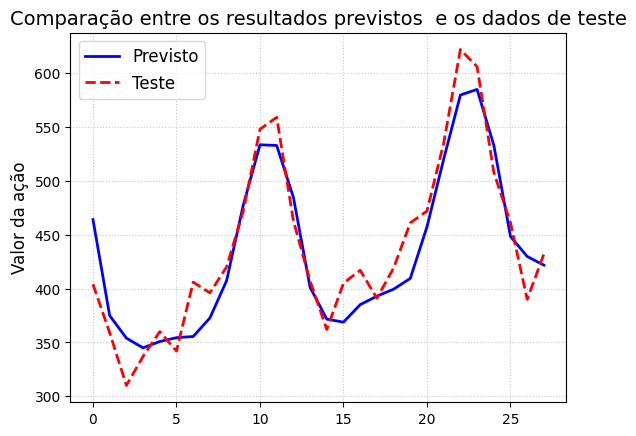

In [34]:
# Plotando as duas curvas

plt.plot( previsores_reais, 'b-', linewidth=2, label='Previsto')      # Curva azul
plt.plot( y_teste, 'r--', linewidth=2, label='Teste')  # Curva vermelha tracejada

# Personalizando o gráfico
plt.title('Comparação entre os resultados previstos  e os dados de teste', fontsize=14)
plt.ylabel('Valor da ação', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)  # Grade pontilhada
plt.legend(fontsize=12, loc='best')  # Legenda


In [35]:
from sklearn.metrics  import  mean_absolute_error

In [36]:
mean_absolute_error(y_teste,previsores_reais)

22.90434380439469